# Module 6: Evaluation & Analysis

This notebook evaluates the performance of:
- Lexical Retrieval
- Neural Retrieval
- Final RAG System

Metrics include:
- Retrieval: Precision@k, Recall@k
- QA: F1 Score, Exact Match

# Step 1 Confirm the environment and import

In [2]:
!pip install pandas

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------------ --------------------------- 3.0/9.9 MB 63.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.9/9.9 MB 72.9 MB/s eta 0:00:01
   ---------------------------------------  9.9/9.9 MB 79.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 70.6 MB/s eta 0:00:00
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     -------------------------------------- 119.8/119.8 kB 7.3 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 50.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/73.5 kB ? eta -:--:--
   ---------------------------------------- 73.5/73.5 kB 4.0 MB/s eta 0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
# 当前目录: e:\comp7125_group_proj-main\module6_evaluation
# 上一级目录: e:\comp7125_group_proj-main
project_root = os.path.dirname(os.getcwd())  # 获取项目根目录
snippets_path = os.path.join(project_root, "output", "snippets.json")

print(f"Project root directory: {project_root}")
print(f"snippets.json Path: {snippets_path}")
print(f"File exists in: {os.path.exists(snippets_path)}")

if os.path.exists(snippets_path):
    with open(snippets_path, "r", encoding="utf-8") as f:
        snippets = json.load(f)
    print(f"✅ successfully loaded {len(snippets)} fragment")
else:
    print("❌ file does not exist")

# 4. 导入实验常用库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime

# 5. 设置可视化样式
plt.style.use('seaborn-v0_8-whitegrid')

Project root directory: e:\comp7125_group_proj-main
snippets.json Path: e:\comp7125_group_proj-main\output\snippets.json
File exists in: True
✅ successfully loaded 32 fragment


# Step 2 Define the test query set
Create 10 representative queries covering different topics：

In [14]:
test_queries = [
    # 课程信息类
    "What are the prerequisites for COMP7125?",
    "When is the final exam for COMP4146?",
    
    # 政策类
    "What is the academic integrity policy?",
    "How do I apply for a course withdrawal?",
    
    # 学习规划类
    "How many credits are required for graduation?",
    "What electives are recommended for AI concentration?",
    
    # 校园生活类
    "Where is the main library?",
    "What student services are available?",
    
    # 综合类
    "How can I improve my GPA?",
    "What should I do if I fail a course?"
]

print(f"Loaded {len(test_queries)} test query")
print("\nQuery by example:")
for i, q in enumerate(test_queries[:3], 1):
    print(f"{i}. {q}")

Loaded 10 test query

Query by example:
1. What are the prerequisites for COMP7125?
2. When is the final exam for COMP4146?
3. What is the academic integrity policy?


# Step 3 Create an evaluation tool class

In [4]:
# Step 3: 创建评估工具类（使用 Module 4 的工具 + Module 2 的检索 + Module 3 的检索）

# Step 3: 创建评估工具类（使用 Module 4 的工具 + Module 2 的检索 + Module 3 的检索）

import sys
import os
import time
import json
import re
from datetime import datetime
from typing import List, Dict, Any, Tuple

# 添加项目根目录到路径
sys.path.append(os.path.abspath(".."))

# 导入 Module 4 的工具
from src.conversation import (
    build_prompt,
    normalize_snippets,
    GenerationConfig,
    build_generation_record,
    DEFAULT_SYSTEM_INSTRUCTION
)

# 导入 Module 3 的 RAGService
from src.rag.service import RAGService

# ============================================
# Module 2 词法检索函数
# ============================================

def preprocess_text(text: str) -> List[str]:
    """Clean and tokenize input text"""
    text = re.sub(r'[^\w\s]', ' ', text.lower())
    return text.split()

def lexical_search(query: str, snippets: List[dict], top_k: int = 3) -> List[Tuple[float, List[str], int]]:
    """BM25-based lexical search"""
    from rank_bm25 import BM25Okapi
    
    snippet_texts = [s["text"] for s in snippets]
    tokenized_texts = [preprocess_text(t) for t in snippet_texts]
    tokenized_query = preprocess_text(query)

    bm25 = BM25Okapi(tokenized_texts)
    scores = bm25.get_scores(tokenized_query)

    top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]

    results = []
    for idx in top_indices:
        overlap_keywords = list(set(tokenized_query) & set(tokenized_texts[idx]))
        results.append((round(scores[idx], 4), overlap_keywords, idx))
    return results

# ============================================
# Ollama packaging
# ============================================

class OllamaChat:
    def __init__(self, model="gemma3:4b", base_url="http://localhost:11434"):
        self.model = model
        self.base_url = base_url
    
    def generate(self, prompt: str, config: GenerationConfig = None) -> Dict:
        import requests
        if config is None:
            config = GenerationConfig()
        
        url = f"{self.base_url}/api/generate"
        payload = {
            "model": self.model,
            "prompt": prompt,
            "stream": False,
            "options": config.to_ollama_options()
        }
        response = requests.post(url, json=payload)
        result = response.json()
        return {
            "text": result.get("response", ""),
            "prompt_tokens": len(prompt.split()),
            "response_tokens": len(result.get("response", "").split()),
        }

# ============================================
# RAGEvaluator class
# ============================================

class RAGEvaluator:
    """RAG 评估器 - 使用 Module 4 的工具 + Module 2 的检索 + Module 3 的检索"""
    
    def __init__(self, snippets: List[dict]):
        self.llm = OllamaChat()
        self.snippets = snippets
        
        # 获取项目根目录（当前文件在 module6_evaluation/ 下）
        project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
        
        course_docs_path = os.path.join(project_root, "course_docs")
        chroma_db_path = os.path.join(project_root, "chroma_db")
        
        print(f"Project root directory: {project_root}")
        print(f"course_docs Path: {course_docs_path}")
        print(f"course_docs exist in: {os.path.exists(course_docs_path)}")
        print(f"chroma_db exist in: {os.path.exists(chroma_db_path)}")
        
        # 初始化 Module 3 的 RAGService，强制重建索引
        self.rag_service = RAGService(
            data_dir=course_docs_path,
            chroma_path=chroma_db_path,
            rebuild_if_changed=True
        )
        
        print(f"✅ The initialization of the evaluator is complete, loaded {len(self.snippets)} fragment")
        print(f"✅ Module 3 RAGService has been initialized, has {self.rag_service.count()} vectors")
    
    
    def answer_no_rag(self, query: str) -> Dict[str, Any]:
        """无检索版本"""
        prompt = build_prompt(
            query=query,
            snippets=[],
            history=None,
            use_history=False,
            system_instruction=DEFAULT_SYSTEM_INSTRUCTION
        )
        
        start_time = time.time()
        response = self.llm.generate(prompt)
        elapsed_ms = (time.time() - start_time) * 1000
        
        return {
            "answer": response["text"],
            "prompt_tokens": response.get("prompt_tokens", len(prompt.split())),
            "response_tokens": response.get("response_tokens", 0),
            "response_time_ms": elapsed_ms,
            "retrieved_snippets": [],
            "prompt": prompt
        }
    
    def answer_lexical_rag(self, query: str, top_k: int = 3) -> Dict[str, Any]:
        """词法检索版本 - 使用 Module 2 的 BM25 检索"""
        if not self.snippets:
            return self.answer_no_rag(query)
        
        # 调用 Module 2 的检索函数
        search_results = lexical_search(query, self.snippets, top_k=top_k)
        
        # 提取检索到的片段，转换为 Module 4 的格式
        retrieved_snippets = []
        for score, keywords, idx in search_results:
            if idx < len(self.snippets):
                snippet = self.snippets[idx]
                retrieved_snippets.append({
                    "citation_key": f"S{idx}",
                    "text": snippet["text"],
                    "meta": {
                        "file_name": snippet.get("file_name", ""),
                        "chunk_id": snippet.get("chunk_id", idx),
                        "score": score,
                        "keywords": keywords,
                        "retriever": "lexical"
                    }
                })
        
        # 使用 Module 4 的 build_prompt
        prompt = build_prompt(
            query=query,
            snippets=retrieved_snippets,
            history=None,
            use_history=False,
            system_instruction=DEFAULT_SYSTEM_INSTRUCTION
        )
        
        start_time = time.time()
        response = self.llm.generate(prompt)
        elapsed_ms = (time.time() - start_time) * 1000
        
        return {
            "answer": response["text"],
            "prompt_tokens": response.get("prompt_tokens", len(prompt.split())),
            "response_tokens": response.get("response_tokens", 0),
            "response_time_ms": elapsed_ms,
            "retrieved_snippets": retrieved_snippets,
            "retrieved_snippets_count": len(retrieved_snippets),
            "prompt": prompt
        }
    
    def answer_neural_rag(self, query: str, top_k: int = 3) -> Dict[str, Any]:
        """神经检索版本 - 使用 Module 3 的 RAGService"""
        try:
            # 使用 Module 3 的 retrieve_chunks 方法
            retrieved_chunks = self.rag_service.retrieve_chunks(query, k=top_k)
            
            # 转换为 Module 4 的格式
            retrieved_snippets = []
            for i, chunk in enumerate(retrieved_chunks):
                retrieved_snippets.append({
                    "citation_key": f"N{i}",
                    "text": chunk.content,
                    "meta": {
                        "file_name": chunk.source,
                        "chunk_id": chunk.chunk_id,
                        "distance": chunk.distance,
                        "start_token": chunk.start_token,
                        "end_token": chunk.end_token,
                        "retriever": "neural"
                    }
                })
            
            # 使用 Module 4 的 build_prompt
            prompt = build_prompt(
                query=query,
                snippets=retrieved_snippets,
                history=None,
                use_history=False,
                system_instruction=DEFAULT_SYSTEM_INSTRUCTION
            )
            
            start_time = time.time()
            response = self.llm.generate(prompt)
            elapsed_ms = (time.time() - start_time) * 1000
            
            return {
                "answer": response["text"],
                "prompt_tokens": response.get("prompt_tokens", len(prompt.split())),
                "response_tokens": response.get("response_tokens", 0),
                "response_time_ms": elapsed_ms,
                "retrieved_snippets": retrieved_snippets,
                "retrieved_snippets_count": len(retrieved_snippets),
                "prompt": prompt
            }
        except Exception as e:
            print(f"⚠️ Module 3 检索失败: {e}")
            return self.answer_no_rag(query)
    
    def run_single(self, query: str, method: str) -> Dict[str, Any]:
        """运行单个查询的单个方法"""
        if method == "no_rag":
            return self.answer_no_rag(query)
        elif method == "lexical_rag":
            return self.answer_lexical_rag(query)
        elif method == "neural_rag":
            return self.answer_neural_rag(query)
        else:
            raise ValueError(f"未知方法: {method}")


# 初始化评估器
evaluator = RAGEvaluator(snippets)
print("All preparations are complete. Let us say: 好！把它们上市!!! ")

Project root directory: e:\comp7125_group_proj-main
course_docs Path: e:\comp7125_group_proj-main\course_docs
course_docs exist in: True
chroma_db exist in: True
✅ The initialization of the evaluator is complete, loaded 32 fragment
✅ Module 3 RAGService has been initialized, has 34 vectors
All preparations are complete. Let us say: 好！把它们上市!!! 


# Step 4 Batch run experiment

Start batch experiments...
Batch Entrez 1/10: What are the prerequisites for COMP7125?...
  - Mode: no_rag
  - Mode: lexical_rag
  - Mode: neural_rag
Batch Entrez 2/10: When is the final exam for COMP4146?...
  - Mode: no_rag
  - Mode: lexical_rag
  - Mode: neural_rag
Batch Entrez 3/10: What is the academic integrity policy?...
  - Mode: no_rag
  - Mode: lexical_rag
  - Mode: neural_rag
Batch Entrez 4/10: How do I apply for a course withdrawal?...
  - Mode: no_rag
  - Mode: lexical_rag
  - Mode: neural_rag
Batch Entrez 5/10: How many credits are required for graduation?...
  - Mode: no_rag
  - Mode: lexical_rag
  - Mode: neural_rag
Batch Entrez 6/10: What electives are recommended for AI concentratio...
  - Mode: no_rag
  - Mode: lexical_rag
  - Mode: neural_rag
Batch Entrez 7/10: Where is the main library?...
  - Mode: no_rag
  - Mode: lexical_rag
  - Mode: neural_rag
Batch Entrez 8/10: What student services are available?...
  - Mode: no_rag
  - Mode: lexical_rag
  - Mode: neural_rag

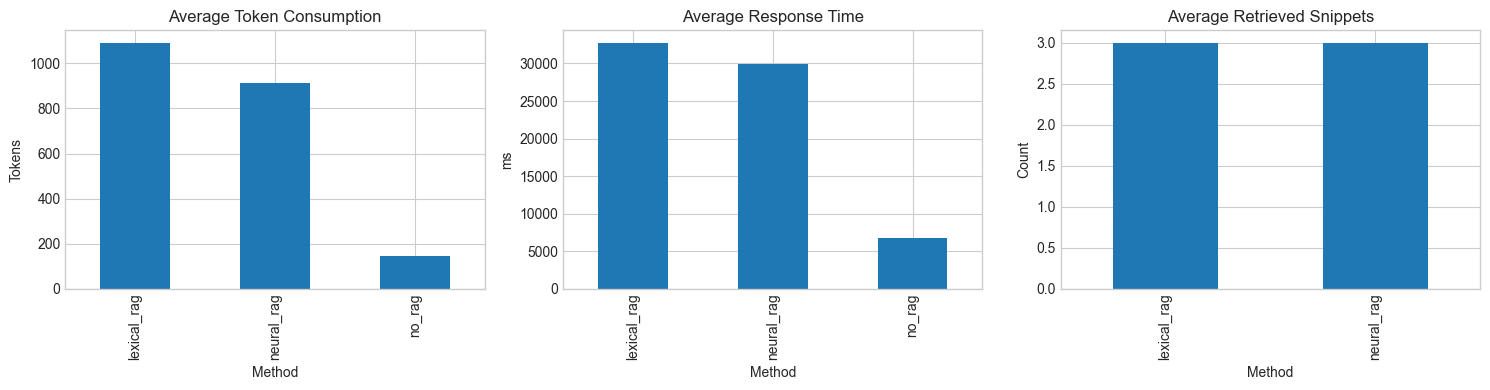


📊 Data preview（First 10 list）:
 query_id                                    query      method  total_tokens  response_time_ms  retrieved_snippets_count
        1 What are the prerequisites for COMP7125?      no_rag           146       6931.086063                         0
        1 What are the prerequisites for COMP7125? lexical_rag           985      25391.998768                         3
        1 What are the prerequisites for COMP7125?  neural_rag           917      26466.882706                         3
        2     When is the final exam for COMP4146?      no_rag           148       6519.914865                         0
        2     When is the final exam for COMP4146? lexical_rag          1152      29794.111967                         3
        2     When is the final exam for COMP4146?  neural_rag           868      27288.439512                         3
        3   What is the academic integrity policy?      no_rag           146       6929.611683                         0


In [ ]:
# Batch run experiments + visual comparison


import os
import time
import pandas as pd
import matplotlib.pyplot as plt

def run_full_experiment(evaluator, queries, modes):
    """批量运行所有查询的所有模式"""
    results = []
    
    for query_id, query in enumerate(queries, start=1):
        print(f"Batch Entrez {query_id}/{len(queries)}: {query[:50]}...")
        
        for mode in modes:
            print(f"  - Mode: {mode}")
            
            try:
                result = evaluator.run_single(query, mode)
                
                # 获取 snippets
                snippets_data = result.get("retrieved_snippets", [])
                
                # 使用 Module 4 的 build_generation_record
                from src.conversation import build_generation_record
                gen_record = build_generation_record(
                    session_id=f"eval_{query_id}_{mode}",
                    query=query,
                    snippets=snippets_data,
                    prompt=result.get("prompt", ""),
                    answer_text=result.get("answer", ""),
                    history=None,
                    use_history=False
                )
                
                record = {
                    "query_id": query_id,
                    "query": query,
                    "method": mode,
                    "answer": result.get("answer", ""),
                    "prompt_tokens": result.get("prompt_tokens", 0),
                    "response_tokens": result.get("response_tokens", 0),
                    "total_tokens": result.get("prompt_tokens", 0) + result.get("response_tokens", 0),
                    "response_time_ms": result.get("response_time_ms", 0),
                    "retrieved_snippets_count": len(snippets_data),
                    "retrieved_snippets_preview": str(snippets_data)[:200],
                    "generation_record": gen_record,
                    "timestamp": datetime.now().isoformat()
                }
                results.append(record)
                
            except Exception as e:
                print(f"    错误: {e}")
                results.append({
                    "query_id": query_id,
                    "query": query,
                    "method": mode,
                    "error": str(e),
                    "timestamp": datetime.now().isoformat()
                })
    
    return pd.DataFrame(results)


def plot_comparison(results_df, save_path=None):
    """绘制三种方法的对比图"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # 1. Token 消耗对比
    results_df.groupby('method')['total_tokens'].mean().plot(kind='bar', ax=axes[0])
    axes[0].set_title('Average Token Consumption')
    axes[0].set_ylabel('Tokens')
    axes[0].set_xlabel('Method')
    
    # 2. 响应时间对比
    results_df.groupby('method')['response_time_ms'].mean().plot(kind='bar', ax=axes[1])
    axes[1].set_title('Average Response Time')
    axes[1].set_ylabel('ms')
    axes[1].set_xlabel('Method')
    
    # 3. 检索片段数对比（仅检索模式有）
    retrieval_data = results_df[results_df['method'].isin(['lexical_rag', 'neural_rag'])]
    if len(retrieval_data) > 0:
        retrieval_counts = retrieval_data.groupby('method')['retrieved_snippets_count'].mean()
        retrieval_counts.plot(kind='bar', ax=axes[2])
        axes[2].set_title('Average Retrieved Snippets')
        axes[2].set_ylabel('Count')
    else:
        axes[2].text(0.5, 0.5, 'No retrieval data', ha='center', va='center')
    axes[2].set_xlabel('Method')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ The comparison chart has been saved in: {save_path}")
    
    plt.show()
    return fig


# ============================================
# 主执行流程
# ============================================

# 定义测试查询（10个）
test_queries = [
    "What are the prerequisites for COMP7125?",
    "When is the final exam for COMP4146?",
    "What is the academic integrity policy?",
    "How do I apply for a course withdrawal?",
    "How many credits are required for graduation?",
    "What electives are recommended for AI concentration?",
    "Where is the main library?",
    "What student services are available?",
    "How can I improve my GPA?",
    "What should I do if I fail a course?"
]

# 定义运行的模式（三种模式）
#modes = ["no_rag", "lexical_rag"]
modes = ["no_rag", "lexical_rag", "neural_rag"]  


# 运行实验
print("=" * 60)
print("Start batch experiments...")
print("=" * 60)
results_df = run_full_experiment(evaluator, test_queries, modes)

# 创建 results 文件夹
os.makedirs("results", exist_ok=True)

# 保存 CSV（带时间戳）
timestamp = time.strftime("%Y%m%d_%H%M%S")
csv_filename = f"results/experiment_results_{timestamp}.csv"
results_df.to_csv(csv_filename, index=False)
print(f"\n✅ Complete! Total {len(results_df)} record")
print(f"📄 CSV has been saved in: {csv_filename}")

# 保存对比图（带时间戳）
png_filename = f"results/comparison_plot_{timestamp}.png"
plot_comparison(results_df, save_path=png_filename)

# 可选：显示前几条记录预览
print("\n📊 Data preview（First 10 list）:")
key_cols = ["query_id", "query", "method", "total_tokens", "response_time_ms", "retrieved_snippets_count"]
print(results_df[key_cols].head(10).to_string(index=False))

# Step 5 Design the LLM-as-a-judge evaluation function

Start LLM-as-a-judge evaluation
evaluating 1/30: no_rag - What are the prerequisites for COMP7125?...
evaluating 2/30: lexical_rag - What are the prerequisites for COMP7125?...
evaluating 3/30: neural_rag - What are the prerequisites for COMP7125?...
evaluating 4/30: no_rag - When is the final exam for COMP4146?...
evaluating 5/30: lexical_rag - When is the final exam for COMP4146?...
evaluating 6/30: neural_rag - When is the final exam for COMP4146?...
evaluating 7/30: no_rag - What is the academic integrity policy?...
evaluating 8/30: lexical_rag - What is the academic integrity policy?...
evaluating 9/30: neural_rag - What is the academic integrity policy?...
evaluating 10/30: no_rag - How do I apply for a course withdrawal?...
evaluating 11/30: lexical_rag - How do I apply for a course withdrawal?...
evaluating 12/30: neural_rag - How do I apply for a course withdrawal?...
evaluating 13/30: no_rag - How many credits are required for gradua...
evaluating 14/30: lexical_rag - How man

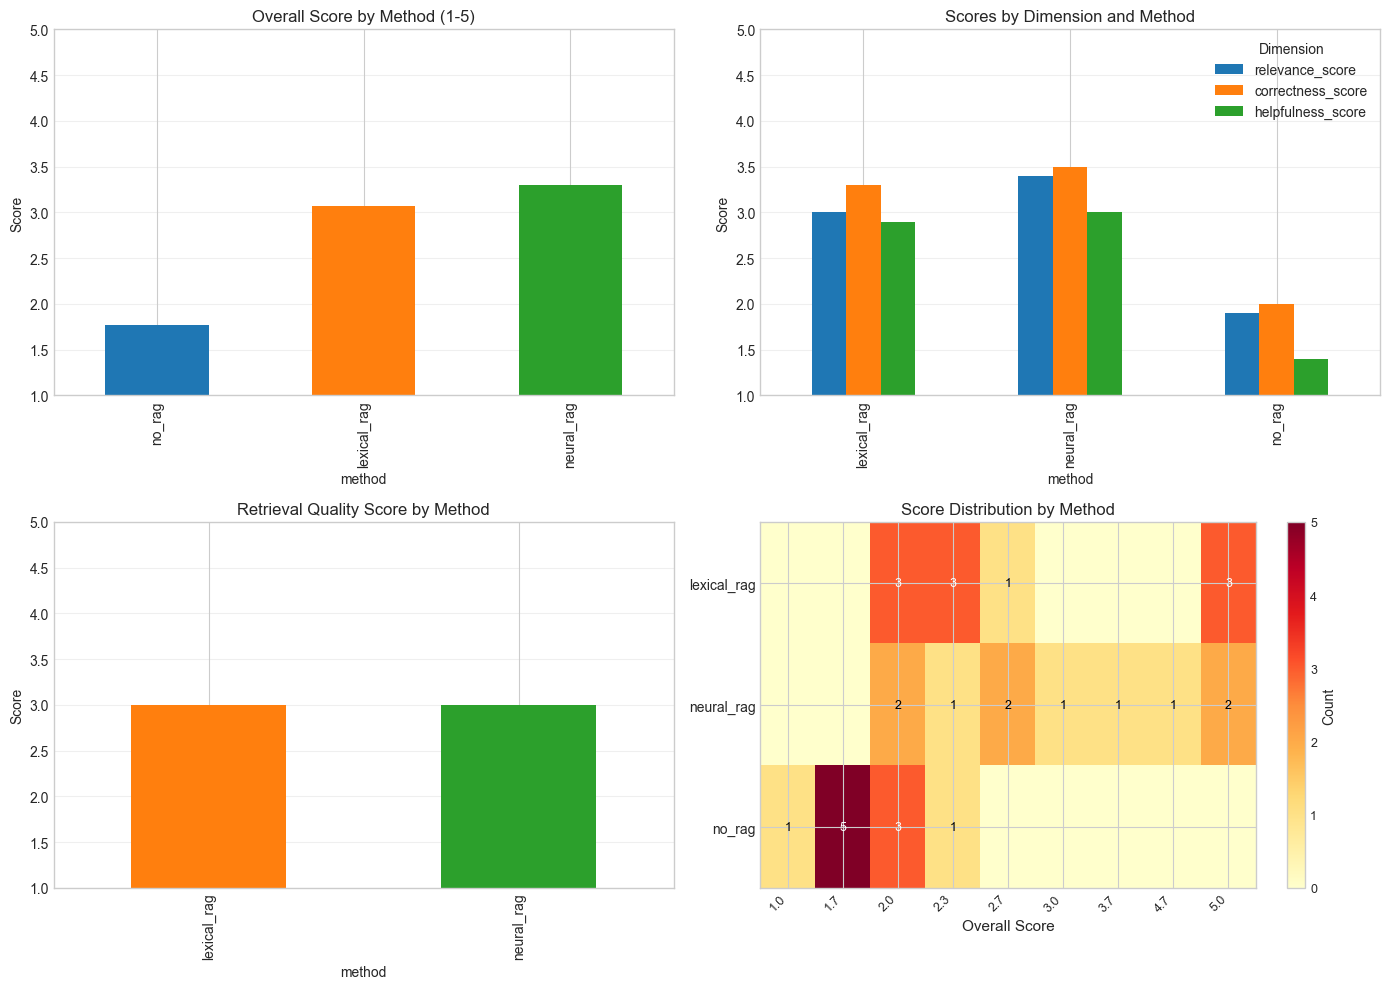


Detailed assessment results (Top 10)
 query_id      method                                    query  relevance_score  correctness_score  helpfulness_score  retrieval_quality_score  overall_score
        1      no_rag What are the prerequisites for COMP7125?              2.0                2.0                1.0                      3.0       1.666667
        1 lexical_rag What are the prerequisites for COMP7125?              2.0                3.0                2.0                      3.0       2.333333
        1  neural_rag What are the prerequisites for COMP7125?              5.0                5.0                4.0                      3.0       4.666667
        2      no_rag     When is the final exam for COMP4146?              2.0                2.0                2.0                      3.0       2.000000
        2 lexical_rag     When is the final exam for COMP4146?              2.0                2.0                2.0                      3.0       2.000000
        2  neu

In [18]:
# ============================================
# LLM-as-a-judge 评估系统
# ============================================

import re
import pandas as pd
import numpy as np
from typing import Dict, List, Optional, Tuple

# 假设你已经有了 OllamaChat 类（来自 Step 4）
# 如果没有，这里重新定义
class OllamaChat:
    def __init__(self, model="gemma3:4b", base_url="http://localhost:11434"):
        self.model = model
        self.base_url = base_url
    
    def generate(self, prompt: str, temperature: float = 0.0, max_tokens: int = 100) -> str:
        import requests
        url = f"{self.base_url}/api/generate"
        payload = {
            "model": self.model,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": temperature,
                "num_predict": max_tokens
            }
        }
        response = requests.post(url, json=payload)
        result = response.json()
        return result.get("response", "").strip()


class LLMJudge:
    """使用 LLM 评估回答质量的评判器"""
    
    def __init__(self, model_name: str = "gemma3:4b"):
        self.llm = OllamaChat(model=model_name)
    
    def evaluate_relevance(self, query: str, answer: str) -> int:
        """评估回答的相关性（1-5分）"""
        prompt = f"""You are an expert evaluator. Rate the relevance of the following answer to the question on a scale of 1 to 5.

Question: {query}

Answer: {answer}

Scoring criteria:
1 - Completely irrelevant, does not address the question
2 - Mostly irrelevant, only tangentially related
3 - Partially relevant, addresses some aspects but misses key points
4 - Mostly relevant, addresses the main points well
5 - Highly relevant, fully and accurately addresses the question

Return ONLY a single number from 1 to 5. Do not add any other text.
"""
        response = self.llm.generate(prompt, temperature=0.0, max_tokens=10)
        try:
            score = int(re.search(r'\d+', response).group())
            return max(1, min(5, score))
        except:
            return 3
    
    def evaluate_correctness(self, query: str, answer: str) -> int:
        """评估回答的正确性（1-5分）"""
        prompt = f"""You are an expert evaluator. Rate the factual correctness of the following answer on a scale of 1 to 5.

Question: {query}

Answer: {answer}

Scoring criteria:
1 - Completely incorrect, contains major factual errors
2 - Mostly incorrect, several errors
3 - Partially correct, some accurate information but also errors
4 - Mostly correct, minor errors or omissions
5 - Completely correct, accurate and complete

Return ONLY a single number from 1 to 5. Do not add any other text.
"""
        response = self.llm.generate(prompt, temperature=0.0, max_tokens=10)
        try:
            score = int(re.search(r'\d+', response).group())
            return max(1, min(5, score))
        except:
            return 3
    
    def evaluate_helpfulness(self, query: str, answer: str) -> int:
        """评估回答的有用性（1-5分）"""
        prompt = f"""You are an expert evaluator. Rate how helpful this answer would be to a user on a scale of 1 to 5.

Question: {query}

Answer: {answer}

Scoring criteria:
1 - Not helpful at all
2 - Slightly helpful
3 - Moderately helpful
4 - Very helpful
5 - Extremely helpful, provides clear and actionable information

Return ONLY a single number from 1 to 5. Do not add any other text.
"""
        response = self.llm.generate(prompt, temperature=0.0, max_tokens=10)
        try:
            score = int(re.search(r'\d+', response).group())
            return max(1, min(5, score))
        except:
            return 3
    
    def evaluate_retrieval_quality(self, query: str, retrieved_snippets: List[Dict]) -> int:
        """评估检索到的片段质量（1-5分）"""
        if not retrieved_snippets:
            return 1
        
        # 提取片段内容
        snippets_text = "\n\n".join([
            f"[{i+1}] {s.get('text', '')[:300]}" 
            for i, s in enumerate(retrieved_snippets[:3])
        ])
        
        prompt = f"""You are an expert evaluator. Rate how relevant the retrieved documents are to the question on a scale of 1 to 5.

Question: {query}

Retrieved documents:
{snippets_text}

Scoring criteria:
1 - Completely irrelevant
2 - Mostly irrelevant
3 - Partially relevant
4 - Mostly relevant
5 - Highly relevant, directly answers the question

Return ONLY a single number from 1 to 5.
"""
        response = self.llm.generate(prompt, temperature=0.0, max_tokens=10)
        try:
            score = int(re.search(r'\d+', response).group())
            return max(1, min(5, score))
        except:
            return 3
    
    def full_evaluation(self, query: str, answer: str, retrieved_snippets: List[Dict] = None) -> Dict[str, int]:
        """综合评估，返回所有指标"""
        result = {
            "relevance": self.evaluate_relevance(query, answer),
            "correctness": self.evaluate_correctness(query, answer),
            "helpfulness": self.evaluate_helpfulness(query, answer),
        }
        if retrieved_snippets:
            result["retrieval_quality"] = self.evaluate_retrieval_quality(query, retrieved_snippets)
        return result


def evaluate_with_llm_judge(results_df: pd.DataFrame, judge: LLMJudge = None) -> pd.DataFrame:
    """
    使用 LLM-as-a-judge 评估所有回答
    """
    if judge is None:
        judge = LLMJudge()
    
    df = results_df.copy()
    
    # 初始化新列（使用浮点数类型）
    df['relevance_score'] = 0.0
    df['correctness_score'] = 0.0
    df['helpfulness_score'] = 0.0
    df['retrieval_quality_score'] = 0.0
    df['overall_score'] = 0.0
    
    total = len(df)
    
    for idx, row in df.iterrows():
        print(f"evaluating {idx+1}/{total}: {row['method']} - {row['query'][:40]}...")
        
        # 获取检索到的片段
        retrieved_snippets = row.get('retrieved_snippets', [])
        if isinstance(retrieved_snippets, str):
            try:
                import ast
                retrieved_snippets = ast.literal_eval(retrieved_snippets)
            except:
                retrieved_snippets = []
        
        # 评估
        scores = judge.full_evaluation(
            query=row['query'],
            answer=row['answer'],
            retrieved_snippets=retrieved_snippets if retrieved_snippets else None
        )
        
        df.at[idx, 'relevance_score'] = float(scores.get('relevance', 3))
        df.at[idx, 'correctness_score'] = float(scores.get('correctness', 3))
        df.at[idx, 'helpfulness_score'] = float(scores.get('helpfulness', 3))
        df.at[idx, 'retrieval_quality_score'] = float(scores.get('retrieval_quality', 3))
        df.at[idx, 'overall_score'] = float(sum(scores.values()) / len(scores))
    
    return df


def plot_llm_judge_results(df: pd.DataFrame, save_path: str = None):
    """可视化 LLM-as-a-judge 评估结果"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. 各方法综合评分对比
    summary = df.groupby('method')['overall_score'].mean().sort_values()
    summary.plot(kind='bar', ax=axes[0, 0], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[0, 0].set_title('Overall Score by Method (1-5)')
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_ylim(1, 5)
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. 各维度评分对比
    metrics = ['relevance_score', 'correctness_score', 'helpfulness_score']
    pivot_data = df.groupby('method')[metrics].mean()
    pivot_data.plot(kind='bar', ax=axes[0, 1])
    axes[0, 1].set_title('Scores by Dimension and Method')
    axes[0, 1].set_ylabel('Score')
    axes[0, 1].set_ylim(1, 5)
    axes[0, 1].legend(title='Dimension')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # 3. 检索质量评分（仅检索模式）
    retrieval_data = df[df['method'].isin(['lexical_rag', 'neural_rag'])]
    if len(retrieval_data) > 0:
        retrieval_scores = retrieval_data.groupby('method')['retrieval_quality_score'].mean()
        retrieval_scores.plot(kind='bar', ax=axes[1, 0], color=['#ff7f0e', '#2ca02c'])
        axes[1, 0].set_title('Retrieval Quality Score by Method')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].set_ylim(1, 5)
        axes[1, 0].grid(axis='y', alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'No retrieval data', ha='center', va='center')
    
    # 4. 评分分布热力图（修复版）
    # 将 overall_score 四舍五入到一位小数，并转换为字符串作为标签
    df['overall_score_rounded'] = df['overall_score'].round(1)
    
    # 创建透视表
    pivot_dist = df.pivot_table(
        index='method', 
        columns='overall_score_rounded', 
        aggfunc='size', 
        fill_value=0
    )
    
    # 创建热力图
    im = axes[1, 1].imshow(pivot_dist.values, cmap='YlOrRd', aspect='auto')
    
    # 设置 x 轴标签（格式化，只显示一位小数）
    x_labels = [f'{x:.1f}' for x in pivot_dist.columns]
    axes[1, 1].set_xticks(range(len(pivot_dist.columns)))
    axes[1, 1].set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
    
    # 设置 y 轴标签
    y_labels = pivot_dist.index.tolist()
    axes[1, 1].set_yticks(range(len(pivot_dist.index)))
    axes[1, 1].set_yticklabels(y_labels, fontsize=10)
    
    axes[1, 1].set_xlabel('Overall Score', fontsize=11)
    axes[1, 1].set_title('Score Distribution by Method', fontsize=12)
    
    # 添加颜色条
    cbar = plt.colorbar(im, ax=axes[1, 1], label='Count')
    cbar.ax.tick_params(labelsize=9)
    
    # 在热力图中添加数值标注（可选）
    for i in range(len(pivot_dist.index)):
        for j in range(len(pivot_dist.columns)):
            val = pivot_dist.iloc[i, j]
            if val > 0:
                axes[1, 1].text(j, i, str(val), ha='center', va='center', 
                                color='white' if val > pivot_dist.values.max()/2 else 'black', fontsize=9)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ The chart has been saved in: {save_path}")
    plt.show()
    return fig


# ============================================
# 主执行流程
# ============================================

print("=" * 60)
print("Start LLM-as-a-judge evaluation")
print("=" * 60)

# 1. 初始化评判器
judge = LLMJudge(model_name="gemma3:4b")

# 2. 评估所有回答
evaluated_df = evaluate_with_llm_judge(results_df, judge)

# 3. 保存评估结果
timestamp = time.strftime("%Y%m%d_%H%M%S")
eval_csv_path = f"results/llm_judge_results_{timestamp}.csv"
evaluated_df.to_csv(eval_csv_path, index=False)
print(f"\n✅ The evaluation results have been saved to: {eval_csv_path}")

# 4. 打印汇总统计
print("\n" + "=" * 60)
print("Evaluation summary statistics")
print("=" * 60)
summary = evaluated_df.groupby('method').agg({
    'relevance_score': 'mean',
    'correctness_score': 'mean',
    'helpfulness_score': 'mean',
    'retrieval_quality_score': 'mean',
    'overall_score': 'mean'
}).round(2)
print(summary)

# 5. 可视化
plot_llm_judge_results(evaluated_df, save_path=f"results/llm_judge_plot_{timestamp}.png")

# 6. 显示详细结果
print("\n" + "=" * 60)
print("Detailed assessment results (Top 10)")
print("=" * 60)
display_cols = ['query_id', 'method', 'query', 'relevance_score', 'correctness_score', 'helpfulness_score', 'retrieval_quality_score', 'overall_score']
print(evaluated_df[display_cols].head(10).to_string(index=False))